In [94]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import string
from tensorflow.keras.preprocessing.sequence import pad_sequences

Get data

In [95]:
BUFFER_SIZE = 10000 
BATCH_SIZE = 32 
NUM_EPOCHS = 10 

In [96]:
from datasets import load_dataset

ds = load_dataset("Teklia/IAM-line")

In [97]:
print(ds)

# get training data
validation_dataset = ds['validation']
test_dataset = ds['test']
train_dataset = ds['train']

x_train, y_train            = [], []
x_test, y_test              = [], []
x_validation, y_validation  = [], []

IMG_WIDTH_RESIZE  = 512
IMG_HEIGHT_RESIZE = 128 

for data in train_dataset:
    img = data['image'].resize((IMG_WIDTH_RESIZE, IMG_HEIGHT_RESIZE))
    txt = data['text']
    x_train.append(np.array(img))
    y_train.append(txt)

for data in test_dataset:
    img = data['image'].resize((IMG_WIDTH_RESIZE, IMG_HEIGHT_RESIZE))
    txt = data['text']
    x_test.append(np.array(img))
    y_test.append(txt)

for data in validation_dataset:
    img = data['image'].resize((IMG_WIDTH_RESIZE, IMG_HEIGHT_RESIZE))
    txt = data['text']
    x_validation.append(np.array(img))
    y_validation.append(txt)


x_train = np.array(x_train)
y_train = np.array(y_train)

x_test  = np.array(x_test)
y_test  = np.array(y_test)

x_validation = np.array(x_validation)
y_validation = np.array(y_validation)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(x_validation.shape, y_validation.shape)


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})
(6482, 128, 512) (6482,)
(2915, 128, 512) (2915,)
(976, 128, 512) (976,)


Reshaping data to fit into model

In [98]:
rows, cols = IMG_HEIGHT_RESIZE, IMG_WIDTH_RESIZE 

# Reshape the data into a 4D Array
x_train = x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test = x_test.reshape(x_test.shape[0], rows, cols, 1)
x_validation = x_validation.reshape(x_validation.shape[0], rows, cols, 1)

# Set type as float32 and normalize the values to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_validation = x_validation.astype('float32') / 255.0

# Text: keep as lists, don't convert to numpy yet
# y_train, y_test, y_validation are still lists of strings

Gets number of classes. Count number of unique letters used in all dataset classifications

In [99]:
# Create character vocabulary
chars = set()
# Convert numpy arrays back to lists for concatenation
y_train_list = y_train.tolist()
y_test_list = y_test.tolist() 
y_validation_list = y_validation.tolist()

for text in y_train_list + y_test_list + y_validation_list:
    chars.update(text)
    
chars = sorted(list(chars))
char_to_int = {char: i for i, char in enumerate(chars)}
int_to_char = {i: char for i, char in enumerate(chars)}

# Encode text to integers
def encode_text(text):
    return [char_to_int[char] for char in text]

# Encode all text data using the list versions
y_train_encoded = [encode_text(text) for text in y_train_list]
y_test_encoded = [encode_text(text) for text in y_test_list]
y_validation_encoded = [encode_text(text) for text in y_validation_list]

num_classes = len(chars) + 1  # +1 for CTC blank token
print(f"Vocabulary size: {num_classes}")

Vocabulary size: 80


Create CNN+BiLSTM+CTC model

In [100]:
# Input shape: (batch_size, height, width, channels)
input_shape = (rows, cols, 1)
inputs = tf.keras.Input(shape=input_shape)

# CNN feature extractor
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (64, 256, 32)

x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (32, 128, 64)

x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (16, 64, 128)

x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (8, 32, 256)

# Reshape CNN output to (sequence_length, feature_dim)
features = layers.Reshape((32, 8*256))(x)        # (batch, 32 steps, 8*256 features)

# BiLSTM layer
lstm_out = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(features)

# Add one extra class for "CTC blank"
outputs = layers.Dense(num_classes, activation="softmax")(lstm_out)

# Define the model
model = models.Model(inputs, outputs)
model.summary()

# Calculate the maximum label length across all datasets
max_label_len = max([len(seq) for seq in y_train_encoded + y_test_encoded + y_validation_encoded])

# Fix the padding value - use 0 instead of -1 for CTC
y_train_padded = pad_sequences(y_train_encoded, maxlen=max_label_len, padding='post', value=0)
y_test_padded = pad_sequences(y_test_encoded, maxlen=max_label_len, padding='post', value=0)
y_validation_padded = pad_sequences(y_validation_encoded, maxlen=max_label_len, padding='post', value=0)

# Better CTC loss function that handles variable-length sequences
def ctc_loss_func(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    
    # Calculate actual label lengths (non-zero values)
    label_length = tf.reduce_sum(tf.cast(y_true > 0, dtype="int64"), axis=1)
    
    input_length = input_length * tf.ones(shape=(batch_len,), dtype="int64")
    
    # Remove padding from y_true for CTC
    y_true_sparse = tf.cast(y_true, dtype="int32")
    
    return tf.reduce_mean(tf.nnx.ctc_loss(
        logits=y_pred,
        labels=y_true_sparse,
        label_length=label_length,
        logit_length=input_length,
        blank_index=num_classes-1  # Use last class as blank
    ))

# Alternative simpler approach - use built-in CTC loss
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CTC(reduction='sum_over_batch_size')
)

history = model.fit(x_train, y_train_padded, epochs=NUM_EPOCHS, validation_data=(x_validation, y_validation_padded), shuffle=True)

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 128, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 64, 256, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 256, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 256, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 32, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 128, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 128, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 8, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 32, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 32, 512)        │     4,720,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32, 80)         │        41,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,151,440 (19.65 MB)

 Trainable params: 5,150,480 (19.65 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - loss: 621.1301 - val_loss: 596.6155
Epoch 2/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - loss: 621.0497 - val_loss: 596.6155
Epoch 3/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - loss: 621.0494 - val_loss: 596.6155
Epoch 4/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - loss: 621.0495 - val_loss: 596.6155
Epoch 5/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - loss: 621.0494 - val_loss: 596.6155
Epoch 6/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - loss: 621.0493 - val_loss: 596.6155
Epoch 7/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - loss: 621.0496 - val_loss: 596.6155
Epoch 8/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - loss: 621.0495 - val_loss: 596.6155
Epoch 9/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - loss: 621.0494 - val_loss: 596.6155
Epoch 10/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - loss: 621.0495 - val_loss: 596.6155


Get sample set

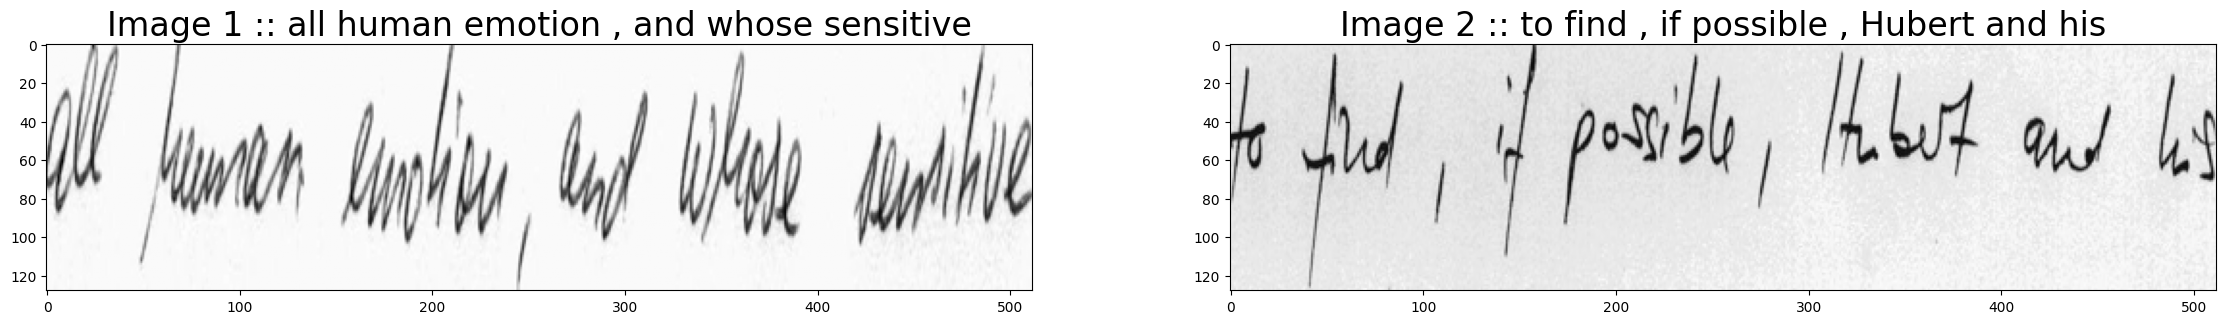

In [106]:
# Plot the Image
DUMMY_BATCH_SIZE = 2
image_index = np.random.randint(0, x_test.shape[0], size=DUMMY_BATCH_SIZE)
dummy_batch = x_test[image_index]
true_labels = y_test[image_index]

fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(28, 28))
for i in range(DUMMY_BATCH_SIZE):
    axes[i].imshow(dummy_batch[i], cmap='gray')
    axes[i].set_title(f"Image {i+1} :: {true_labels[i]}", fontsize=24)


Show CNN output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
CNN features shape: (2, 8, 32, 256)


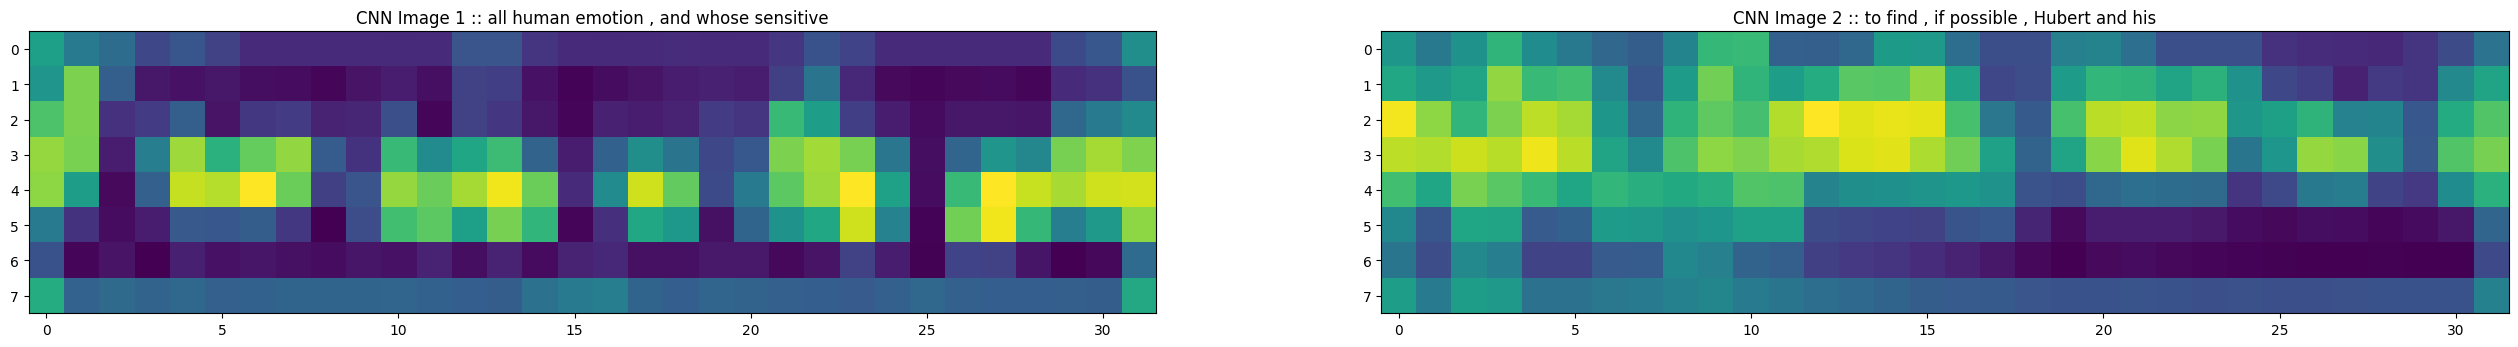

In [107]:
TEST_IMG_ROW = 32
TEST_IMG_COL = 8

# Get CNN features for dummy_images
# cnn_model = models.Model(inputs, features)
cnn_model = models.Model(inputs, x)
cnn_features = cnn_model.predict(dummy_batch)

print("CNN features shape:", cnn_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(TEST_IMG_ROW, TEST_IMG_COL))
for i in range(DUMMY_BATCH_SIZE):
    # Show the mean across channels for visualization
    axes[i].imshow(np.mean(cnn_features[i], axis=-1), cmap='viridis')
    # axes[i].imshow(cnn_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"CNN Image {i+1} :: {true_labels[i]}")



Show BiLSTM output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
BiLSTM features shape: (2, 32, 512)


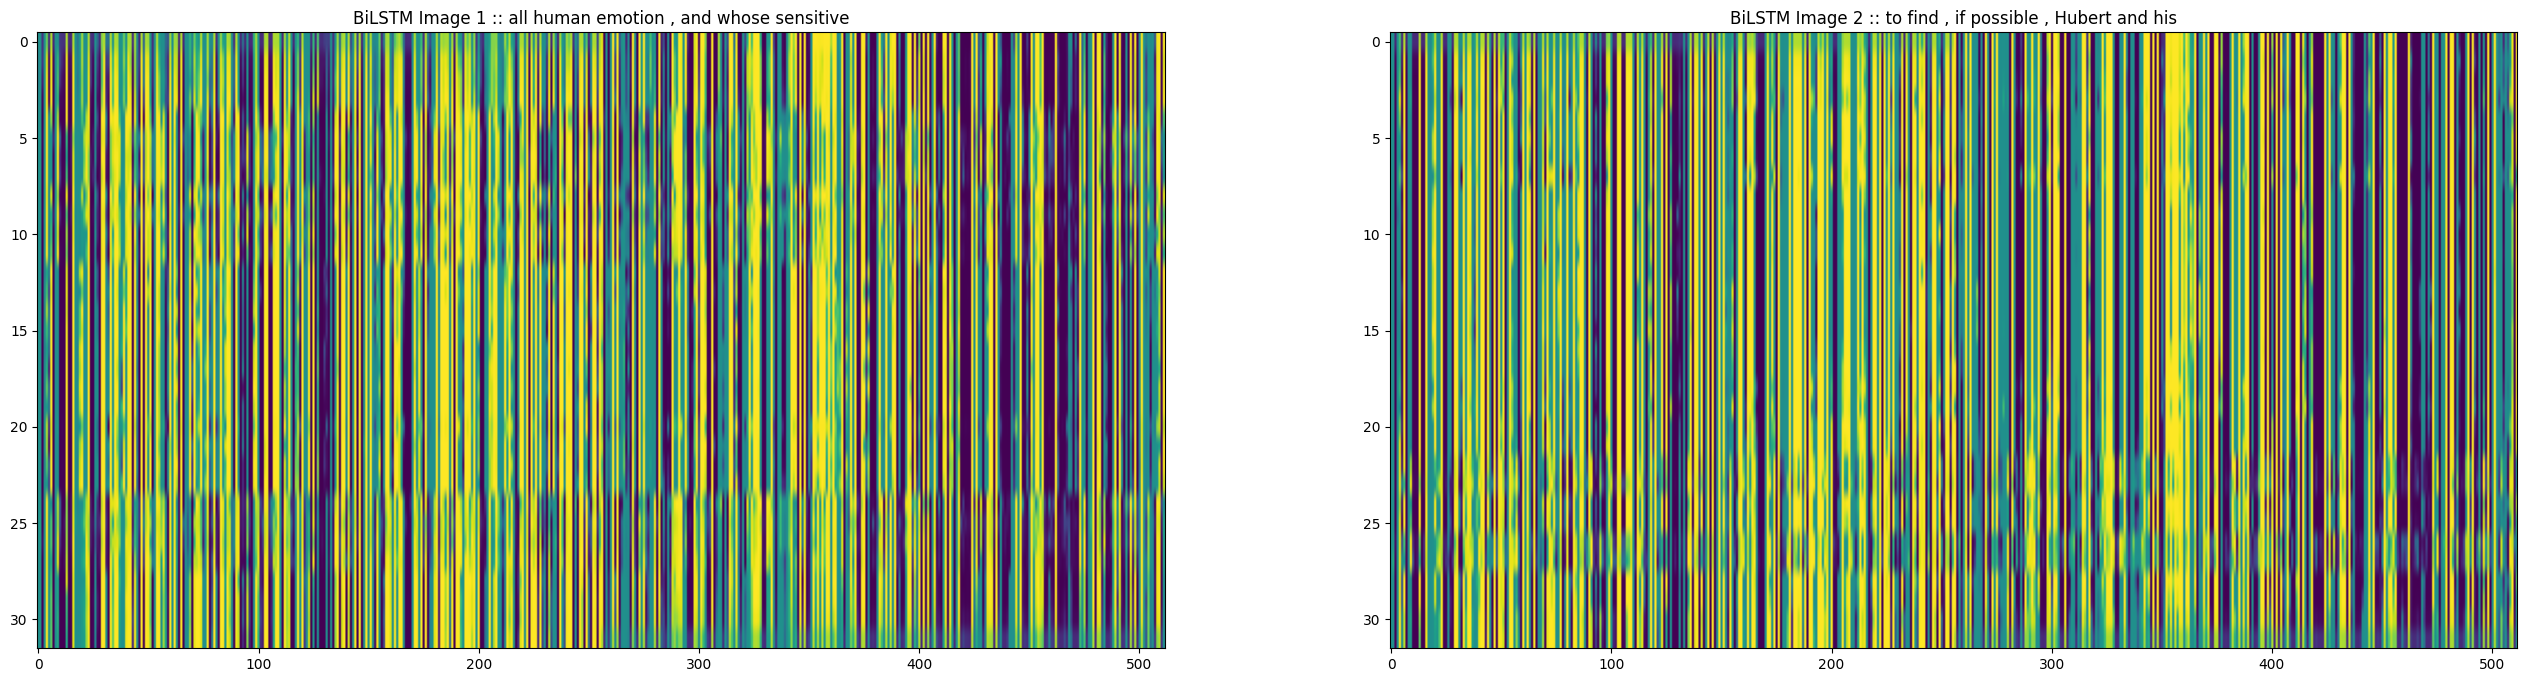

In [109]:
biLSTM = models.Model(inputs, lstm_out)
biLSTM_features = biLSTM.predict(dummy_batch)

print("BiLSTM features shape:", biLSTM_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(TEST_IMG_ROW, TEST_IMG_COL))
for i in range(DUMMY_BATCH_SIZE):
    # Show the BiLSTM output as a heatmap: shape (7, 11)
    axes[i].imshow(biLSTM_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"BiLSTM Image {i+1} :: {true_labels[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Full output shape: (2, 32, 80)


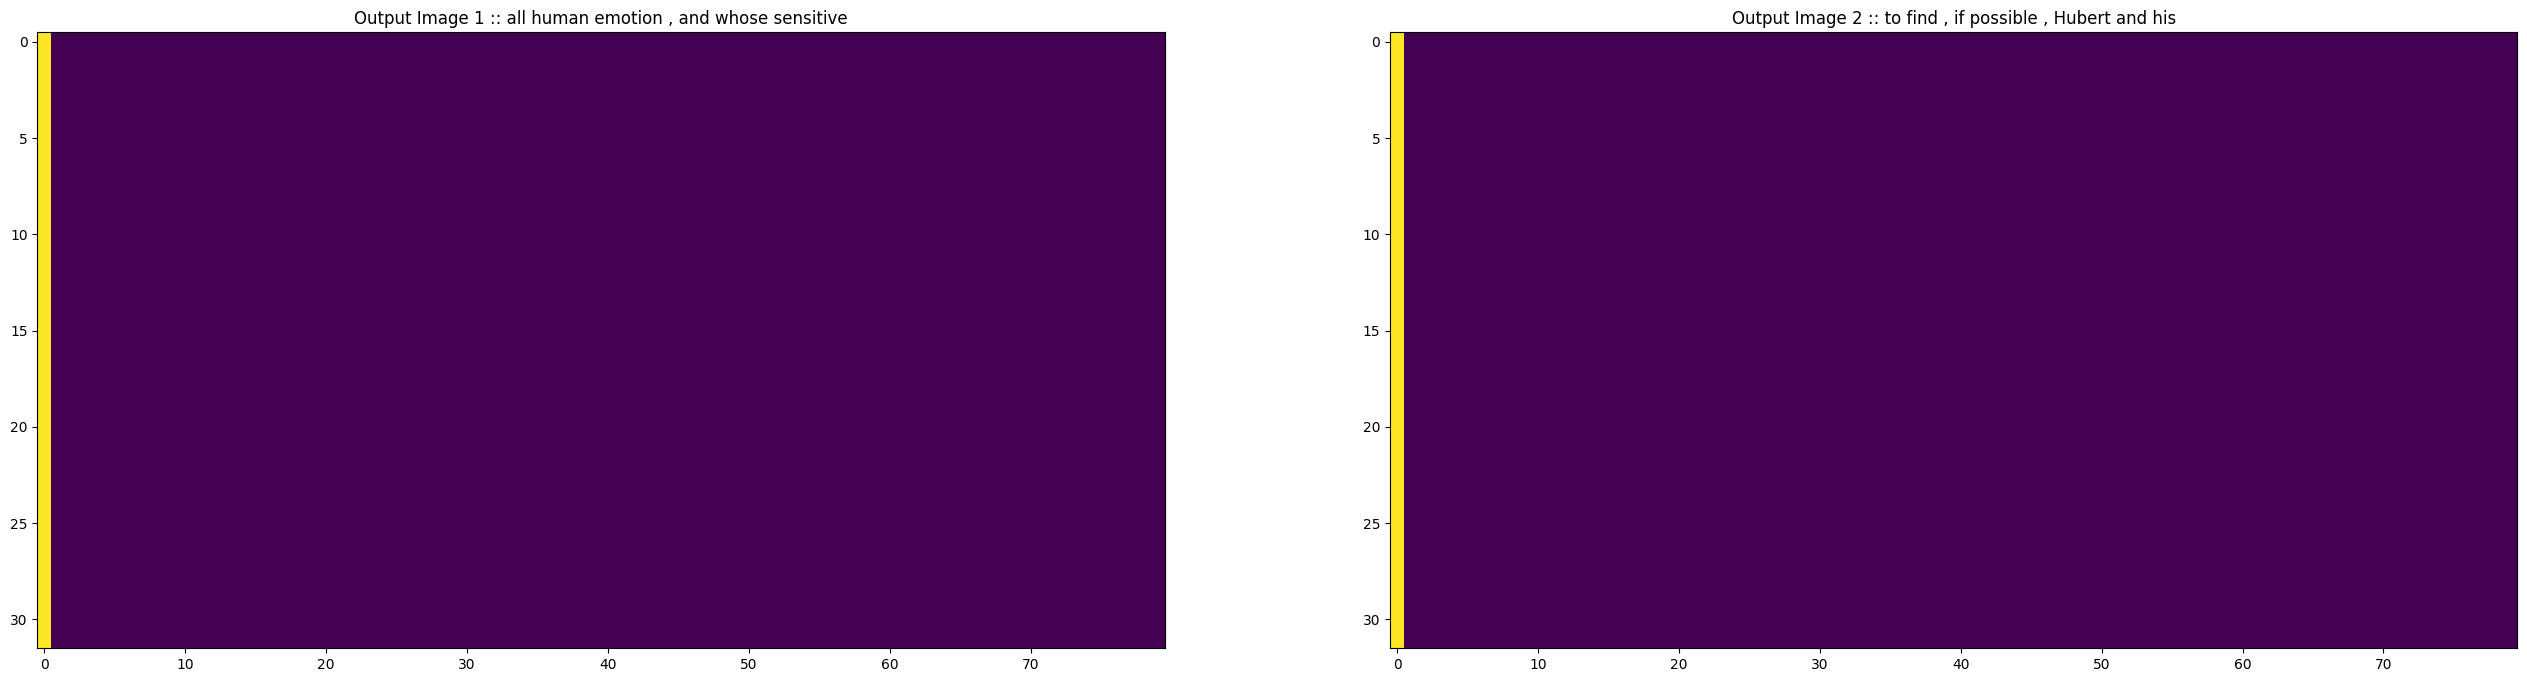

In [108]:
output_model = models.Model(inputs, outputs)
output_features = output_model.predict(dummy_batch)

print("Full output shape:", output_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(TEST_IMG_ROW, TEST_IMG_COL))
for i in range(DUMMY_BATCH_SIZE):
    axes[i].imshow(output_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"Output Image {i+1} :: {true_labels[i]}")

Sample 0: Predicted text: ' '
Sample 1: Predicted text: ' '


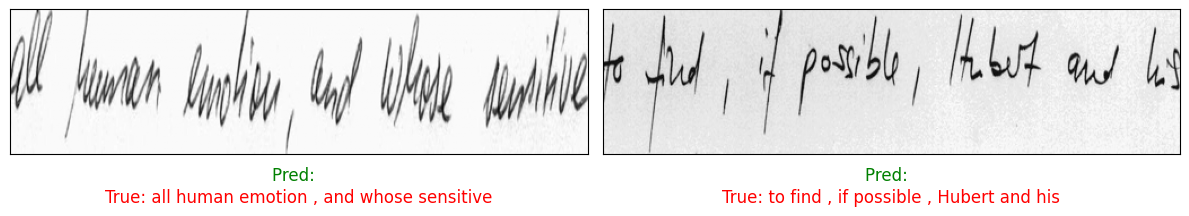

In [110]:
raw_preds = output_features

# Perform CTC decoding using tf.nn.ctc_greedy_decoder
# tf.nn.ctc_greedy_decoder expects inputs with shape [time_steps, batch_size, num_classes]
# Our model output has shape [batch_size, time_steps, num_classes], so we need to transpose it.
transposed_preds = tf.transpose(raw_preds, perm=[1, 0, 2])

# tf.nn.ctc_greedy_decoder also expects log probabilities.
log_probs = tf.math.log(transposed_preds + tf.keras.backend.epsilon())

# The `sequence_length` is the length of the sequence for each example in the batch.
batch_size = tf.shape(raw_preds)[0]
input_length = tf.fill([batch_size], tf.shape(raw_preds)[1])

# Perform CTC greedy decoding
decoded_preds, log_prob = tf.nn.ctc_greedy_decoder(log_probs, input_length)

# Convert the sparse tensor to a dense tensor for easier handling.
decoded_preds_dense = tf.sparse.to_dense(decoded_preds[0], default_value=-1)

def decode_prediction(predictions):
    """Convert integer predictions back to characters"""
    text = ""
    for pred in predictions:
        if pred != -1 and pred < len(int_to_char):  # Skip padding and check bounds
            text += int_to_char[pred]
    return text

# Decode each sample in the batch separately
predictions_text = []
for i in range(DUMMY_BATCH_SIZE):
    # Get predictions for this sample
    sample_preds = decoded_preds_dense[i].numpy().tolist()
    # Remove -1 padding values
    sample_preds = [p for p in sample_preds if p != -1]
    
    # Convert to text
    predicted_text = decode_prediction(sample_preds)
    predictions_text.append(predicted_text)
    print(f"Sample {i}: Predicted text: '{predicted_text}'")

# Display images with decoded predictions
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(12, 8))
if DUMMY_BATCH_SIZE == 1:
    axes = [axes]  # Make it iterable for single subplot

for i in range(DUMMY_BATCH_SIZE):
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    img = dummy_batch[i].squeeze()  # Remove channel dimension
    axes[i].imshow(img, cmap='gray')
    
    # Display the decoded text
    axes[i].text(0.5, -0.15, f'Pred: {predictions_text[i]}', size=12, color='green',
                horizontalalignment='center', verticalalignment='center',
                transform=axes[i].transAxes)

    # Display the true label for comparison
    axes[i].text(0.5, -0.3, f'True: {true_labels[i]}', size=12, color='red',
                horizontalalignment='center', verticalalignment='center',
                transform=axes[i].transAxes)

plt.tight_layout()
plt.show()
